HEAD shape (10, 10)
HEAD type <class 'numpy.ndarray'>


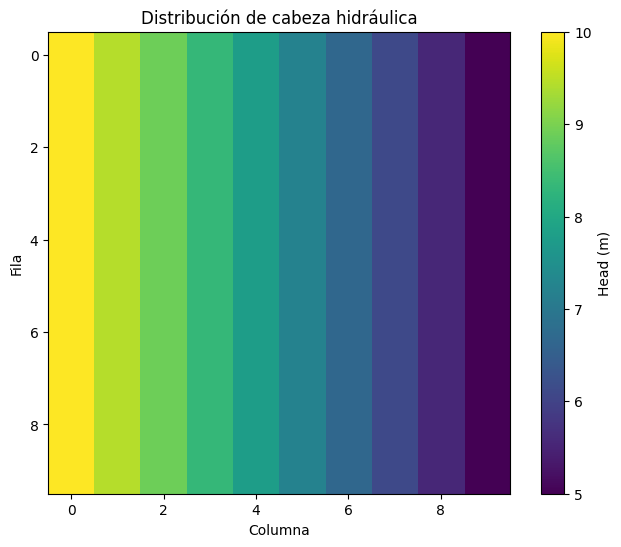

In [6]:
import flopy
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Configuración general ---
model_name = "sandbox"
sim_ws = "./mf6_sandbox"

sim = flopy.mf6.MFSimulation(
    sim_name=model_name,
    version="mf6",
    exe_name='../../bin/windows/mf6',
    sim_ws=sim_ws
)

# --- 2. Tiempos de simulación ---
tdis = flopy.mf6.ModflowTdis(
    sim,
    time_units="DAYS",
    nper=1,
    perioddata=[(1.0, 1, 1.0)],
)

# --- 3. Solucionador numérico (IMS) ---
ims = flopy.mf6.ModflowIms(
    sim,
    print_option="SUMMARY",
#    complexity="SIMPLE",
#    outer_dvclose=1e-4,
#    outer_maximum=50,
#    under_relaxation="NONE",
#    linear_acceleration="CG",
#    inner_maximum=30,
#    inner_dvclose=1e-6,
)
# Nota: la solución se enlazará al modelo más adelante

# --- 4. Modelo GWF ---
gwf = flopy.mf6.ModflowGwf(
    sim,
    modelname=model_name,
    model_nam_file=f"{model_name}.nam",
    save_flows=True
)

# --- 5. Grid del modelo ---
nlay, nrow, ncol = 1, 10, 10
delr = delc = 0.1
top = 0.0
botm = -1.0

dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top=top,
    botm=botm,
)

# --- 6. Propiedades hidráulicas ---
ic = flopy.mf6.ModflowGwfic(
    gwf,
    strt=10.0  # condición inicial
)

npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    save_flows=True,
    icelltype=1,  # flujo en la cara superior
    k=1.0,        # conductividad hidráulica (constante)
)

# --- 7. Condiciones de frontera (BCF) ---
# Izquierda (col=0): cabeza fija a 10
# Derecha (col=9): cabeza fija a 5
chd_data = []
for row in range(nrow):
    chd_data.append([(0, row, 0), 10.0])
    chd_data.append([(0, row, ncol - 1), 5.0])

chd = flopy.mf6.ModflowGwfchd(
    gwf,
    stress_period_data=chd_data,
#    pname="CHD-1", # Cuando no se pone usa 'CHD_0', puede ser cualquier string
#    save_flows=True,
)

#print("CHD len", len(chd_data))
#[print(ic) for ic in chd_data]

# --- 8. Presiones y cabezas ---
head = flopy.mf6.ModflowGwfoc(
    gwf,
    budget_filerecord=f"{model_name}.cbc",
    head_filerecord=f"{model_name}.hds",
    saverecord=[("HEAD", "ALL")],
    printrecord=[("HEAD", "ALL")]
)

# --- 9. Registrar solución numérica al modelo ---
sim.register_solution_package(ims, [gwf.name])

# --- 10. Ejecutar ---
sim.write_simulation(silent=True)
sim.run_simulation(silent=True)

# --- 11. Leer resultados ---
headfile = f"{sim_ws}/{model_name}.hds"
hds = flopy.utils.HeadFile(headfile)
head = hds.get_data(mflay=0) # Solo se obtiene la capa 0, cuando no se pone
                             # ningún valor se obtienen todas las capas

print("HEAD shape", head.shape)
print("HEAD type", type(head))

# --- 12. Visualizar ---
plt.figure(figsize=(8, 6))
plt.imshow(head, cmap="viridis", origin="upper")
plt.colorbar(label="Head (m)")
plt.title("Distribución de cabeza hidráulica")
plt.xlabel("Columna")
plt.ylabel("Fila")
plt.show()
